# Escalado y Normalizacion de Datos en Machine Learning

## Por que es importante escalar los datos?

En muchos algoritmos de Machine Learning, las variables con magnitudes grandes dominan sobre las de magnitudes pequenas. Si una variable va de 0 a 1000 y otra de 0 a 1, el modelo puede interpretar erróneamente que la primera es "mas importante" simplemente por su escala.

**El escalado garantiza que todas las variables contribuyan de forma equitativa al modelo.**

---

## Algoritmos que NECESITAN escalado

| Algoritmo | Razon |
|-----------|-------|
| **SVM** (Support Vector Machines) | Calcula distancias entre puntos; variables con mayor rango dominan la frontera de decision |
| **KNN** (K-Nearest Neighbors) | Basado en distancias euclidianas; escala desigual sesga la similitud |
| **Redes Neuronales** | Gradientes se desestabilizan con magnitudes muy dispares |
| **PCA** (Analisis de Componentes Principales) | Maximiza varianza; variables con mayor rango acaparan los componentes |
| **K-Means** | Usa distancias para asignar clusters; escala afecta la agrupacion |
| **Regresion Lineal/Logistica regularizada** | L1/L2 penalizan coeficientes; escala afecta la penalizacion |

## Algoritmos que NO necesitan escalado

| Algoritmo | Razon |
|-----------|-------|
| **Arboles de Decision** | Dividen por umbrales en cada variable de forma independiente |
| **Random Forest** | Conjunto de arboles; invariante a escala |
| **XGBoost / LightGBM / CatBoost** | Basados en arboles; no usan distancias |

> **Regla practica:** si el algoritmo usa distancias, gradientes o regularizacion, necesita escalado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
    Normalizer,
    PowerTransformer,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# --- Configuracion visual ---
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = sns.color_palette("viridis", 6)
COLOR_ORIGINAL = PALETTE[0]
COLOR_SCALED = PALETTE[3]
COLOR_HIGHLIGHT = PALETTE[5]

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})

print("Imports y configuracion visual listos.")

Imports y configuracion visual listos.


## 1. MinMaxScaler

### Formula

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Transforma cada variable al rango **[0, 1]** (por defecto). Se puede configurar a cualquier rango `[a, b]`.

### Cuando usarlo

- Cuando se necesita un rango acotado (por ejemplo, para redes neuronales con activaciones sigmoid/tanh).
- Cuando la distribucion **no es necesariamente gaussiana**.
- Cuando no hay outliers significativos.

### Sensibilidad a outliers

**Alta.** Un solo valor extremo comprime todos los demas valores hacia un extremo del rango. Si `X_max` es un outlier, el 99% de los datos quedara cerca de 0.

Datos originales:     [10. 20. 30. 40. 50.]
Min = 10.0, Max = 50.0
Calculo manual:       [0.   0.25 0.5  0.75 1.  ]
Resultado sklearn:    [0.   0.25 0.5  0.75 1.  ]
Coinciden? True


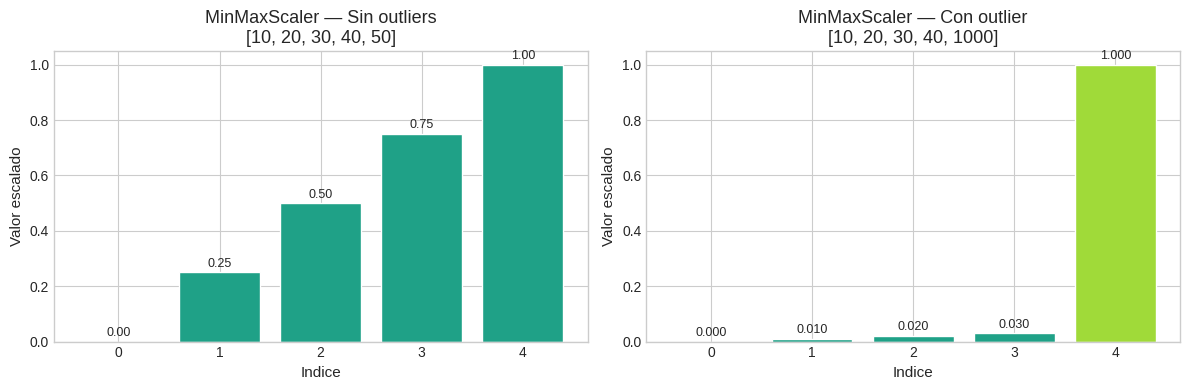


Observacion: el outlier (1000) comprime los valores normales cerca de 0.


In [2]:
# --- MinMaxScaler: paso a paso manual ---
datos = np.array([10, 20, 30, 40, 50], dtype=float)

# Calculo manual
x_min = datos.min()
x_max = datos.max()
manual_scaled = (datos - x_min) / (x_max - x_min)

print("Datos originales:    ", datos)
print(f"Min = {x_min}, Max = {x_max}")
print("Calculo manual:      ", manual_scaled)

# Verificacion con sklearn
scaler = MinMaxScaler()
sklearn_scaled = scaler.fit_transform(datos.reshape(-1, 1)).flatten()
print("Resultado sklearn:   ", sklearn_scaled)
print(f"Coinciden? {np.allclose(manual_scaled, sklearn_scaled)}")

# --- Efecto de outliers ---
datos_outlier = np.array([10, 20, 30, 40, 1000], dtype=float)
scaled_outlier = MinMaxScaler().fit_transform(datos_outlier.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sin outliers
axes[0].bar(range(len(datos)), manual_scaled, color=COLOR_SCALED, edgecolor='white')
axes[0].set_title("MinMaxScaler — Sin outliers\n[10, 20, 30, 40, 50]")
axes[0].set_ylabel("Valor escalado")
axes[0].set_xlabel("Indice")
for i, v in enumerate(manual_scaled):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)

# Con outliers
colors = [COLOR_SCALED] * 4 + [COLOR_HIGHLIGHT]
axes[1].bar(range(len(datos_outlier)), scaled_outlier, color=colors, edgecolor='white')
axes[1].set_title("MinMaxScaler — Con outlier\n[10, 20, 30, 40, 1000]")
axes[1].set_ylabel("Valor escalado")
axes[1].set_xlabel("Indice")
for i, v in enumerate(scaled_outlier):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nObservacion: el outlier (1000) comprime los valores normales cerca de 0.")

## 2. StandardScaler (Estandarizacion Z-Score)

### Formula

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviacion estandar de la variable.

### Resultado

- **Media = 0**, **Desviacion estandar = 1**
- El rango NO esta acotado (puede ir de $-\infty$ a $+\infty$).

### Cuando usarlo

- Cuando el algoritmo asume datos con distribucion gaussiana (regresion logistica, LDA).
- Cuando se necesita que los datos esten centrados en 0.
- Es el escalador mas comun y el **punto de partida por defecto**.

Datos originales:     [10. 20. 30. 40. 50.]
Media = 30.0, Desviacion estandar = 14.1421
Calculo manual (z):   [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Resultado sklearn:    [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Coinciden? True

Media tras escalar:  0.0000000000  (aprox 0)
Std tras escalar:    1.0000000000  (aprox 1)


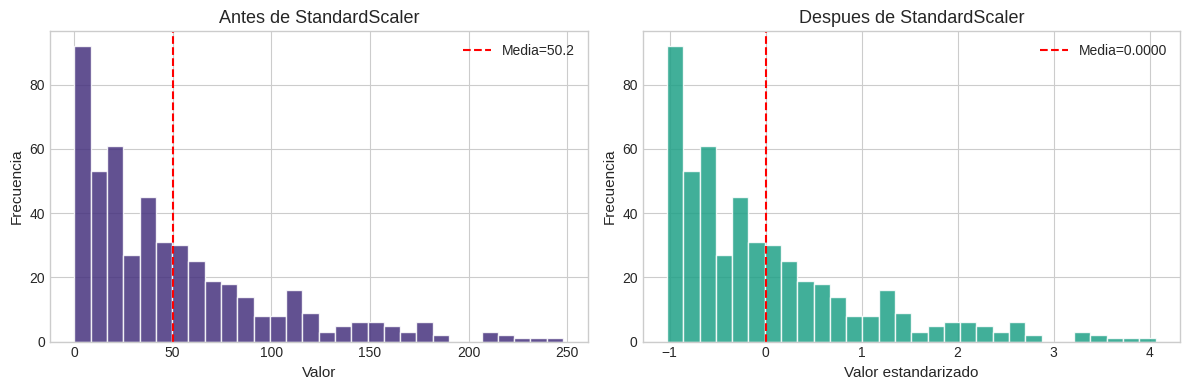

Nota: la forma de la distribucion NO cambia, solo la escala y el centro.


In [3]:
# --- StandardScaler: paso a paso manual ---
datos = np.array([10, 20, 30, 40, 50], dtype=float)

# Calculo manual
mu = datos.mean()
sigma = datos.std()  # std poblacional (ddof=0), igual que sklearn
manual_z = (datos - mu) / sigma

print("Datos originales:    ", datos)
print(f"Media = {mu}, Desviacion estandar = {sigma:.4f}")
print("Calculo manual (z):  ", manual_z)

# Verificacion con sklearn
scaler = StandardScaler()
sklearn_z = scaler.fit_transform(datos.reshape(-1, 1)).flatten()
print("Resultado sklearn:   ", sklearn_z)
print(f"Coinciden? {np.allclose(manual_z, sklearn_z)}")
print(f"\nMedia tras escalar:  {sklearn_z.mean():.10f}  (aprox 0)")
print(f"Std tras escalar:    {sklearn_z.std():.10f}  (aprox 1)")

# --- Histograma antes/despues ---
np.random.seed(42)
datos_dist = np.random.exponential(scale=50, size=500)
datos_z = StandardScaler().fit_transform(datos_dist.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(datos_dist, bins=30, color=COLOR_ORIGINAL, edgecolor='white', alpha=0.85)
axes[0].axvline(datos_dist.mean(), color='red', linestyle='--', label=f"Media={datos_dist.mean():.1f}")
axes[0].set_title("Antes de StandardScaler")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(datos_z, bins=30, color=COLOR_SCALED, edgecolor='white', alpha=0.85)
axes[1].axvline(datos_z.mean(), color='red', linestyle='--', label=f"Media={datos_z.mean():.4f}")
axes[1].set_title("Despues de StandardScaler")
axes[1].set_xlabel("Valor estandarizado")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Nota: la forma de la distribucion NO cambia, solo la escala y el centro.")

## 3. RobustScaler

### Formula

$$X_{scaled} = \frac{X - Q_2}{IQR}$$

Donde:
- $Q_2$ = mediana (percentil 50)
- $IQR = Q_3 - Q_1$ = rango intercuartilico (percentil 75 - percentil 25)

### Caracteristica clave

**Robusto a outliers.** Al usar la mediana y el IQR en lugar de la media y la desviacion estandar, los valores extremos no distorsionan la transformacion.

### Cuando usarlo

- Cuando los datos tienen outliers que no se pueden eliminar.
- Cuando se quiere mantener la estructura central de los datos sin que los extremos dominen.

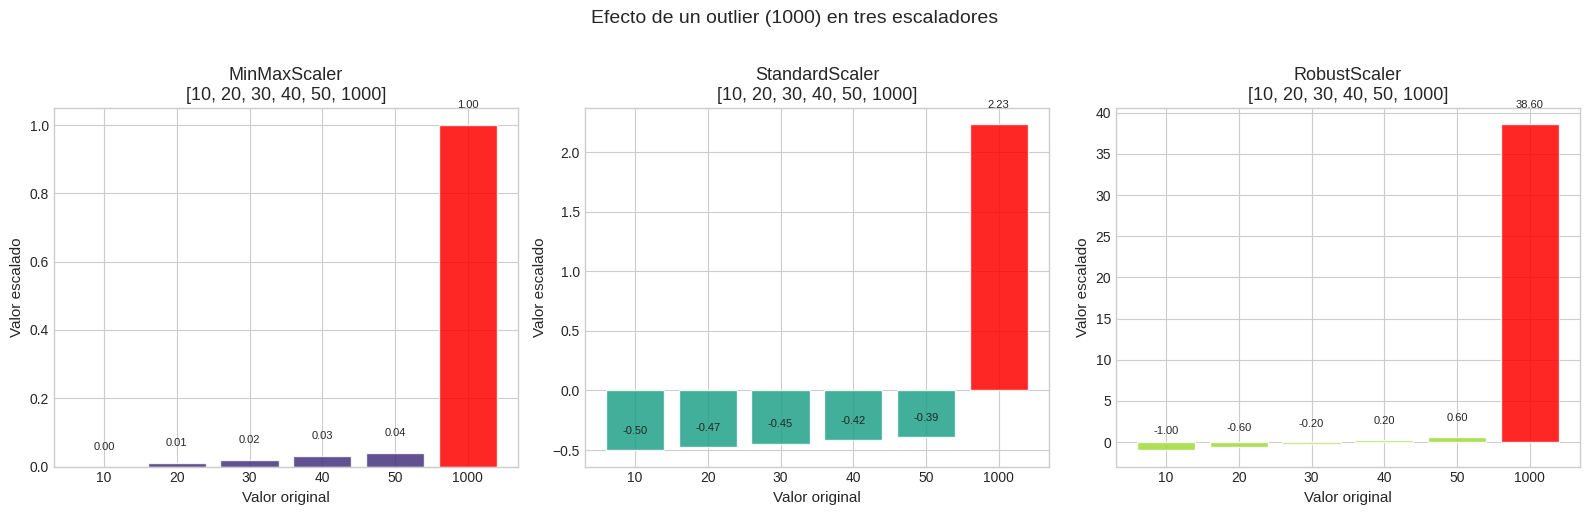

Observaciones:
- MinMaxScaler: los valores normales quedan comprimidos cerca de 0.
- StandardScaler: el outlier distorsiona media y std, afectando a todos.
- RobustScaler: los valores normales mantienen separacion razonable.


In [4]:
# --- Comparacion: MinMaxScaler vs StandardScaler vs RobustScaler con outliers ---
datos_outlier = np.array([10, 20, 30, 40, 50, 1000], dtype=float)

minmax = MinMaxScaler().fit_transform(datos_outlier.reshape(-1, 1)).flatten()
standard = StandardScaler().fit_transform(datos_outlier.reshape(-1, 1)).flatten()
robust = RobustScaler().fit_transform(datos_outlier.reshape(-1, 1)).flatten()

etiquetas = [str(int(v)) for v in datos_outlier]
x_pos = np.arange(len(datos_outlier))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scalers_data = [
    ("MinMaxScaler", minmax, COLOR_ORIGINAL),
    ("StandardScaler", standard, COLOR_SCALED),
    ("RobustScaler", robust, COLOR_HIGHLIGHT),
]

for ax, (nombre, vals, color) in zip(axes, scalers_data):
    colors_bar = [color] * (len(vals) - 1) + ['red']
    ax.bar(x_pos, vals, color=colors_bar, edgecolor='white', alpha=0.85)
    ax.set_title(f"{nombre}\n[10, 20, 30, 40, 50, 1000]")
    ax.set_xlabel("Valor original")
    ax.set_ylabel("Valor escalado")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(etiquetas)
    for i, v in enumerate(vals):
        offset = 0.05 * (max(vals) - min(vals)) if max(vals) != min(vals) else 0.02
        ax.text(i, v + offset, f"{v:.2f}", ha='center', fontsize=8)

plt.suptitle("Efecto de un outlier (1000) en tres escaladores", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("- MinMaxScaler: los valores normales quedan comprimidos cerca de 0.")
print("- StandardScaler: el outlier distorsiona media y std, afectando a todos.")
print("- RobustScaler: los valores normales mantienen separacion razonable.")

## 4. Otros escaladores y normalizadores

### MaxAbsScaler

$$X_{scaled} = \frac{X}{|X_{max}|}$$

- Escala al rango **[-1, 1]** sin centrar (no desplaza la media).
- **Preserva la esparsidad** de matrices sparse (no introduce ceros donde habia valores nulos).
- Ideal para datos sparse como matrices TF-IDF o datos one-hot encoded.

### Normalizer (L1 y L2)

Opera **por fila** (por muestra), no por columna:

- **L1:** cada fila se divide por la suma de sus valores absolutos. Los elementos suman 1.
- **L2:** cada fila se divide por su norma euclidiana. El vector tiene magnitud 1.

Util cuando la **direccion** del vector importa mas que su magnitud (por ejemplo, en comparacion de documentos con TF-IDF).

### PowerTransformer

Aplica transformaciones de potencia para hacer que los datos se aproximen a una **distribucion gaussiana**:

- **Yeo-Johnson:** acepta valores negativos y ceros.
- **Box-Cox:** solo valores estrictamente positivos.

Ideal para datos con **alta asimetria (skewness)**, como variables de ingreso, precios o tiempos de espera.

=== MaxAbsScaler con datos sparse ===
Matriz sparse original — elementos no-cero: 4
[[0 0 3 0]
 [0 5 0 0]
 [7 0 0 2]
 [0 0 0 0]]

Tras MaxAbsScaler — elementos no-cero: 4
Sigue siendo sparse? True
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 1.]
 [0. 0. 0. 0.]]

--- Comparacion: StandardScaler destruye esparsidad ---
Tras StandardScaler(with_mean=False) — elementos no-cero: 4
(Con with_mean=True daria error porque centrar elimina la esparsidad)

=== PowerTransformer en datos asimetricos ===
Skewness antes:   1.8650
Skewness despues: 0.0690


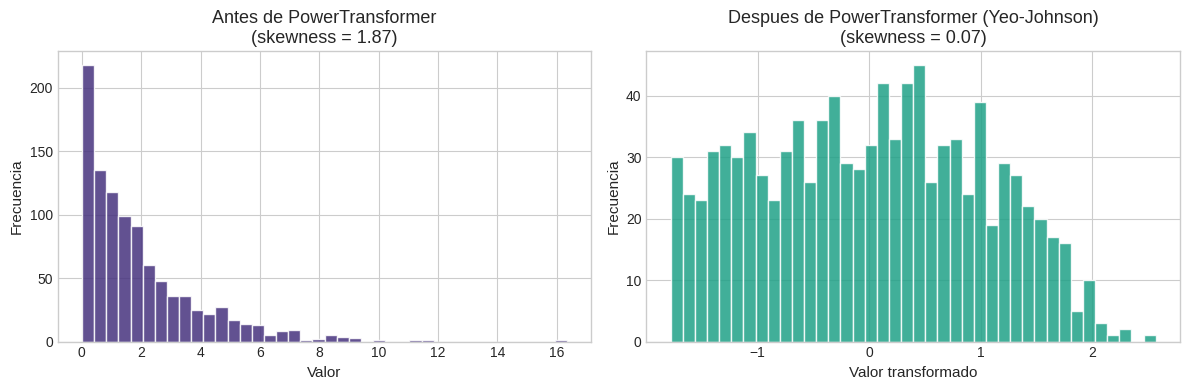

PowerTransformer convierte una distribucion asimetrica en algo cercano a gaussiana.


In [5]:
# --- MaxAbsScaler: preservacion de esparsidad ---
# Crear una matriz sparse con muchos ceros
datos_sparse = sparse.csr_matrix(np.array([
    [0, 0, 3, 0],
    [0, 5, 0, 0],
    [7, 0, 0, 2],
    [0, 0, 0, 0],
]))

print("=== MaxAbsScaler con datos sparse ===")
print(f"Matriz sparse original — elementos no-cero: {datos_sparse.nnz}")
print(datos_sparse.toarray())

# MaxAbsScaler preserva esparsidad
maxabs = MaxAbsScaler()
datos_maxabs = maxabs.fit_transform(datos_sparse)
print(f"\nTras MaxAbsScaler — elementos no-cero: {datos_maxabs.nnz}")
print(f"Sigue siendo sparse? {sparse.issparse(datos_maxabs)}")
print(datos_maxabs.toarray())

# StandardScaler NO preserva esparsidad (centra los datos)
print("\n--- Comparacion: StandardScaler destruye esparsidad ---")
standard = StandardScaler(with_mean=False)  # with_mean=True daria error en sparse
datos_std = standard.fit_transform(datos_sparse)
print(f"Tras StandardScaler(with_mean=False) — elementos no-cero: {datos_std.nnz}")
print("(Con with_mean=True daria error porque centrar elimina la esparsidad)")

# --- PowerTransformer en datos asimetricos ---
print("\n=== PowerTransformer en datos asimetricos ===")
np.random.seed(42)
datos_skewed = np.random.exponential(scale=2, size=1000)

pt = PowerTransformer(method='yeo-johnson')
datos_transformed = pt.fit_transform(datos_skewed.reshape(-1, 1)).flatten()

from scipy.stats import skew
print(f"Skewness antes:   {skew(datos_skewed):.4f}")
print(f"Skewness despues: {skew(datos_transformed):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(datos_skewed, bins=40, color=COLOR_ORIGINAL, edgecolor='white', alpha=0.85)
axes[0].set_title(f"Antes de PowerTransformer\n(skewness = {skew(datos_skewed):.2f})")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(datos_transformed, bins=40, color=COLOR_SCALED, edgecolor='white', alpha=0.85)
axes[1].set_title(f"Despues de PowerTransformer (Yeo-Johnson)\n(skewness = {skew(datos_transformed):.2f})")
axes[1].set_xlabel("Valor transformado")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print("PowerTransformer convierte una distribucion asimetrica en algo cercano a gaussiana.")

## 5. fit() vs transform() vs fit_transform() — y el Data Leakage

### Los tres metodos

| Metodo | Que hace |
|--------|----------|
| `scaler.fit(X)` | **Aprende** los parametros (media, std, min, max, etc.) a partir de `X`. No transforma nada. |
| `scaler.transform(X)` | **Aplica** la transformacion usando los parametros ya aprendidos. |
| `scaler.fit_transform(X)` | Hace `fit` + `transform` en un solo paso. Equivale a `scaler.fit(X).transform(X)`. |

### Data Leakage (fuga de datos)

El **data leakage** ocurre cuando informacion del conjunto de test se filtra al entrenamiento. En el contexto del escalado:

**INCORRECTO** (produce data leakage):
```python
# El scaler aprende estadisticas de TODO el dataset, incluyendo test
scaler.fit(X_completo)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

**CORRECTO** (sin data leakage):
```python
# El scaler SOLO aprende del train
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # usa parametros del train
```

> **Regla de oro:** el scaler se ajusta (fit) UNICAMENTE con datos de entrenamiento. El test se transforma con los parametros aprendidos del train.

In [6]:
# --- Inspeccion de parametros aprendidos por fit() ---
datos = np.array([10, 20, 30, 40, 50], dtype=float).reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(datos)

print("=== Parametros aprendidos por StandardScaler.fit() ===")
print(f"scaler.mean_  = {scaler.mean_}")
print(f"scaler.scale_ = {scaler.scale_}  (desviacion estandar)")
print(f"scaler.var_   = {scaler.var_}    (varianza)")
print(f"scaler.n_features_in_ = {scaler.n_features_in_}")

# --- Demostracion de Data Leakage ---
print("\n=== Efecto del Data Leakage en metricas ===")
np.random.seed(42)
X, y = make_classification(
    n_samples=500, n_features=20, n_informative=5,
    n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- INCORRECTO: fit en todo el dataset (data leakage) ---
scaler_leak = StandardScaler()
scaler_leak.fit(X)  # Aprende de TODOS los datos, incluyendo test
X_train_leak = scaler_leak.transform(X_train)
X_test_leak = scaler_leak.transform(X_test)

modelo_leak = LogisticRegression(max_iter=1000, random_state=42)
modelo_leak.fit(X_train_leak, y_train)
acc_leak = accuracy_score(y_test, modelo_leak.predict(X_test_leak))

# --- CORRECTO: fit solo en train ---
scaler_ok = StandardScaler()
scaler_ok.fit(X_train)  # Solo aprende del train
X_train_ok = scaler_ok.transform(X_train)
X_test_ok = scaler_ok.transform(X_test)

modelo_ok = LogisticRegression(max_iter=1000, random_state=42)
modelo_ok.fit(X_train_ok, y_train)
acc_ok = accuracy_score(y_test, modelo_ok.predict(X_test_ok))

print(f"Accuracy CON data leakage:   {acc_leak:.4f}")
print(f"Accuracy SIN data leakage:   {acc_ok:.4f}")
print(f"Diferencia:                  {abs(acc_leak - acc_ok):.4f}")

# Mostrar que los parametros difieren
print(f"\nMedia del scaler con leakage (feat 0):  {scaler_leak.mean_[0]:.4f}")
print(f"Media del scaler sin leakage (feat 0):  {scaler_ok.mean_[0]:.4f}")
print("Los parametros son diferentes porque el scaler con leakage")
print("incluyo informacion del test en sus estadisticas.")

=== Parametros aprendidos por StandardScaler.fit() ===
scaler.mean_  = [30.]
scaler.scale_ = [14.14213562]  (desviacion estandar)
scaler.var_   = [200.]    (varianza)
scaler.n_features_in_ = 1

=== Efecto del Data Leakage en metricas ===
Accuracy CON data leakage:   0.8533
Accuracy SIN data leakage:   0.8533
Diferencia:                  0.0000

Media del scaler con leakage (feat 0):  0.4912
Media del scaler sin leakage (feat 0):  0.4956
Los parametros son diferentes porque el scaler con leakage
incluyo informacion del test en sus estadisticas.


## 6. Escalado por grupo (caso de uso: mantenimiento predictivo)

En proyectos de **mantenimiento predictivo** (como el dataset C-MAPSS), los datos provienen de multiples unidades (motores, turbinas, etc.). Cada unidad opera en condiciones diferentes, por lo que **escalar globalmente mezcla distribuciones distintas**.

### Estrategia correcta: escalar por grupo

En lugar de aplicar un unico scaler a todo el dataset, se ajusta un scaler **independiente por cada unidad/motor**:

```python
for motor_id in df['unit_id'].unique():
    mask = df['unit_id'] == motor_id
    scaler = StandardScaler()
    df.loc[mask, features] = scaler.fit_transform(df.loc[mask, features])
```

Esto asegura que las estadisticas (media, std) reflejen el comportamiento normal de **cada unidad individual**, no el promedio global de todas las unidades.

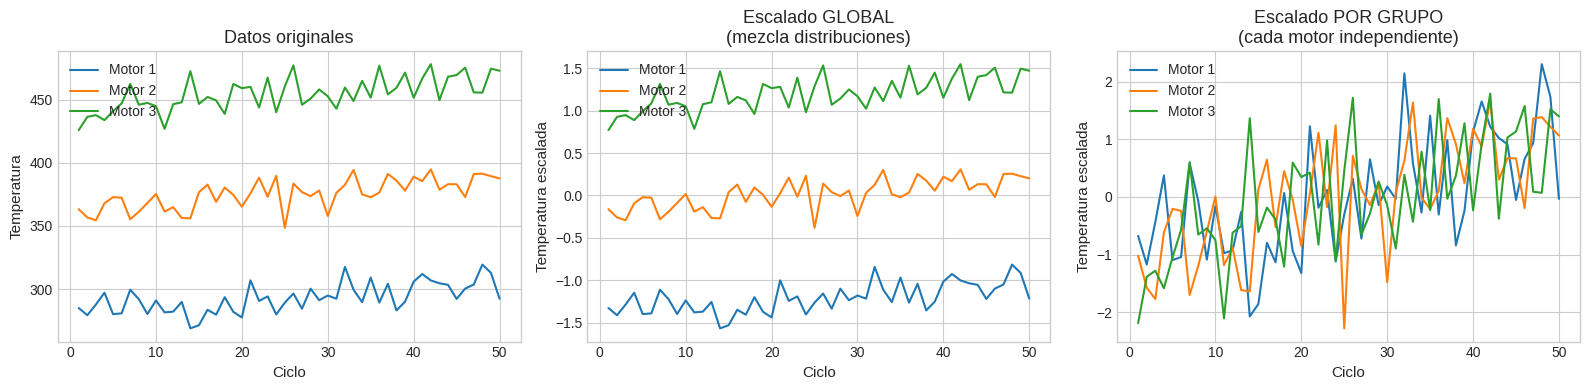

Con escalado por grupo, las tendencias de degradacion de cada motor
son comparables entre si, sin que las diferencias de nivel base las enmascaren.


In [7]:
# --- Escalado por grupo: simulacion multi-motor ---
import pandas as pd

np.random.seed(42)

# Simular 3 motores con diferentes niveles base de temperatura
motores = []
for motor_id in range(1, 4):
    n_ciclos = 50
    base_temp = 200 + motor_id * 80  # Cada motor tiene distinta temperatura base
    temp = base_temp + np.random.normal(0, 10, n_ciclos) + np.linspace(0, 30, n_ciclos)
    df_motor = pd.DataFrame({
        'unit_id': motor_id,
        'ciclo': range(1, n_ciclos + 1),
        'temperatura': temp
    })
    motores.append(df_motor)

df = pd.concat(motores, ignore_index=True)

# --- Escalado GLOBAL vs POR GRUPO ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Datos originales
for mid in df['unit_id'].unique():
    mask = df['unit_id'] == mid
    axes[0].plot(df.loc[mask, 'ciclo'], df.loc[mask, 'temperatura'], label=f'Motor {mid}')
axes[0].set_title("Datos originales")
axes[0].set_xlabel("Ciclo")
axes[0].set_ylabel("Temperatura")
axes[0].legend()

# 2. Escalado GLOBAL (incorrecto para este caso)
scaler_global = StandardScaler()
df['temp_global'] = scaler_global.fit_transform(df[['temperatura']])
for mid in df['unit_id'].unique():
    mask = df['unit_id'] == mid
    axes[1].plot(df.loc[mask, 'ciclo'], df.loc[mask, 'temp_global'], label=f'Motor {mid}')
axes[1].set_title("Escalado GLOBAL\n(mezcla distribuciones)")
axes[1].set_xlabel("Ciclo")
axes[1].set_ylabel("Temperatura escalada")
axes[1].legend()

# 3. Escalado POR GRUPO (correcto)
df['temp_grupo'] = 0.0
for mid in df['unit_id'].unique():
    mask = df['unit_id'] == mid
    scaler_grupo = StandardScaler()
    df.loc[mask, 'temp_grupo'] = scaler_grupo.fit_transform(
        df.loc[mask, ['temperatura']]
    ).flatten()

for mid in df['unit_id'].unique():
    mask = df['unit_id'] == mid
    axes[2].plot(df.loc[mask, 'ciclo'], df.loc[mask, 'temp_grupo'], label=f'Motor {mid}')
axes[2].set_title("Escalado POR GRUPO\n(cada motor independiente)")
axes[2].set_xlabel("Ciclo")
axes[2].set_ylabel("Temperatura escalada")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Con escalado por grupo, las tendencias de degradacion de cada motor")
print("son comparables entre si, sin que las diferencias de nivel base las enmascaren.")

## 7. Diagrama de decision y tabla resumen

### Como elegir el escalador correcto?

```
                        Tus datos tienen outliers?
                        /                         \
                      SI                           NO
                      |                             |
               RobustScaler               La distribucion es gaussiana?
                                          /                            \
                                        SI                              NO
                                        |                               |
                                  StandardScaler                  MinMaxScaler
                                                                        |
                                                          Datos sparse? --> MaxAbsScaler
                                                          Alta asimetria? --> PowerTransformer
```

### Tabla resumen de escaladores

| Escalador | Formula | Rango resultado | Sensible a outliers? | Preserva sparse? | Centra los datos? |
|-----------|---------|-----------------|----------------------|-------------------|-------------------|
| **MinMaxScaler** | $(X - X_{min}) / (X_{max} - X_{min})$ | [0, 1] | Si | No | Si |
| **StandardScaler** | $(X - \mu) / \sigma$ | Sin limite | Moderadamente | No | Si |
| **RobustScaler** | $(X - Q_2) / IQR$ | Sin limite | No | No | Si |
| **MaxAbsScaler** | $X / |X_{max}|$ | [-1, 1] | Si | Si | No |
| **Normalizer L2** | $X / \|X\|_2$ | [-1, 1] por fila | No | No | No |
| **PowerTransformer** | Yeo-Johnson / Box-Cox | Sin limite | Moderadamente | No | Si |

### Recomendaciones finales

1. **Empezar siempre con StandardScaler** salvo que haya una razon especifica para otro.
2. **Outliers presentes** --> usar RobustScaler.
3. **Redes neuronales con sigmoid/tanh** --> MinMaxScaler a [0, 1].
4. **Datos sparse (TF-IDF, one-hot)** --> MaxAbsScaler.
5. **Distribuciones muy asimetricas** --> PowerTransformer antes de escalar.
6. **Siempre hacer fit SOLO en train**, nunca en el dataset completo.
7. **Datos agrupados** (multiples unidades/pacientes/sensores) --> escalar por grupo.